This notebook is meant to be an exploratory data analysis on a given dataset: California Housing Prices

In [2]:
# Import packages to use
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import scipy

### 1. IMPORT THE DATA

In [3]:
# Import dataset to work on
import urllib.request 
data_path = 'https://raw.githubusercontent.com/nyandwi/public_datasets/master/housing.csv'
data_path =  urllib.request.urlretrieve(data_path)[0]
df = pd.read_csv(data_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Columns in the dataframe
1. ``longitude``:            A measure of how far west a house is; a higher value is farther west
2. ``latitude``:            A measure of how far north a house is; a higher value is farther north
3. ``housingMedianAge``:    Median age of a house within a block; a lower number is a newer building
4. ``totalRooms``:          Total number of rooms within a block
5. ``totalBedrooms``:       Total number of bedrooms within a block
6. ``population``:          Total number of people residing within a block
7. ``households``:          Total number of households, a group of people residing within a home unit, for a block
8. ``medianIncome``:        Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. ``medianHouseValue``:    Median house value for households within a block (measured in US Dollars)
10. ``oceanProximity``:     Location of the house w.r.t ocean/sea

### 2. DATA STRUCTURE

In [42]:
# Now we can start exploring the dataset
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


The dataframe has most of columns has float64, and only one is marked as object (string in this case)

In [57]:
print(df.select_dtypes(include="number").columns.tolist())
print(df.select_dtypes(include="object").columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
['ocean_proximity']


### 3. STANDARDIZE COLUMN NAMES

In [60]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
# Fix data type and import errors with 'coerce'
df["feature"] = pd.to_datetime(df["feature"], errors="coerce")
df["feature"] = pd.to_numeric(df["feature"], errors="coerce")
df["feature"] = df["feature"].astype("category")
df["feature"] = df["feature"].astype(str)

### 4. MISSING VALUES

In [61]:
df.isnull().sum()
#df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [62]:
# Percentage of missing values
df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

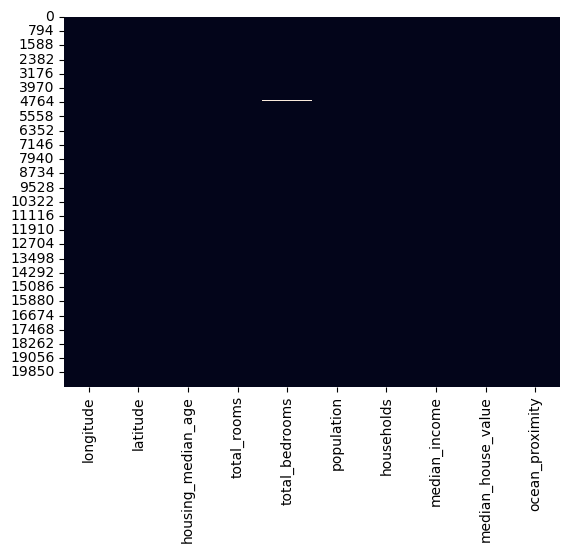

In [65]:
# Visualize missing values
sns.heatmap(df.isna(), cbar=False)
plt.show()

### 5. HANDLE MISSING VALUES

In [ ]:
# Missing values can be dropped
df.dropna(inplace=True)

# Drop column contaminated by missing values
df.drop(columns=["column_name"], inplace=True)

In [ ]:
# Missing values can be filled
df['column_name'].fillna(0, inplace=True)
df['column_name'].fillna('Unknown', inplace=True)
df['column_name'].fillna(df['column_name'].mean(), inplace=True)    # mean
df['column_name'].fillna(df['column_name'].median(), inplace=True)  # median
df['column_name'].fillna(df['column_name'].mode()[0], inplace=True) # mode
df['column_name'].fillna(method="ffill", inplace=True)              # forward filling
df['column_name'].fillna(method="bfill", inplace=True)              # backward filling
df["y_linear"] = df["column_name"].interpolate(method="linear")          # Linear interpolation
df["y_cubic"]  = df["column_name"].interpolate(method="spline", order=3) # Cubic spline interpolation

# Interpolate multiple numerical cols
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_area="inside")

In [ ]:
# Missing values can be filled by stratum in "group_column"
df['column_name'] = df.groupby("group_column")['column_name'].transform(
    lambda x: x.fillna(x.median())
)

In [18]:
# Missing values can be imputed (univariate imputation, similar to filling missing values with mean, median, or mode)
from sklearn.impute import SimpleImputer
housing_numeric=df.drop('ocean_proximity', axis=1)  # Simple imputer only work with numeric features, so we drop the OCEAN_PROXIMITY
mean_fill=SimpleImputer(missing_values=np.nan, strategy='mean')
mean_fill.fit(housing_numeric)
housing_numeric_mean_filled=mean_fill.transform(housing_numeric)
housing_numeric_mean_filled = pd.DataFrame(housing_numeric_mean_filled, columns=housing_numeric.columns)
housing_numeric_mean_filled.head()  

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,latitude_normalized,longitude_normalized,latitude_standardized,longitude_standardized,latitude_robust_scaled,households_robust_scaled,longitude_robust_scaled
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.567481,0.211155,1.052548,-0.986807,0.957672,-0.870769,-0.986807
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.565356,0.212151,1.043185,-0.984169,0.952381,2.243077,-0.984169
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.564293,0.210159,1.038503,-0.989446,0.949735,-0.713846,-0.989446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.584615,-0.992084
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.461538,-0.992084


In [19]:
# Missing values can be imputed using other features (multivariate imputation)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(random_state=0)
housing_numeric_imputed = imputer.fit_transform(housing_numeric)
housing_numeric_imputed = pd.DataFrame(housing_numeric_imputed, columns=housing_numeric.columns)
housing_numeric_imputed.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,latitude_normalized,longitude_normalized,latitude_standardized,longitude_standardized,latitude_robust_scaled,households_robust_scaled,longitude_robust_scaled
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.567481,0.211155,1.052548,-0.986807,0.957672,-0.870769,-0.986807
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.565356,0.212151,1.043185,-0.984169,0.952381,2.243077,-0.984169
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.564293,0.210159,1.038503,-0.989446,0.949735,-0.713846,-0.989446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.584615,-0.992084
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.461538,-0.992084


In [20]:
# Missing values can be imputed using KNN imputation
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
housing_numeric_knn_imputed = imputer.fit_transform(housing_numeric)
housing_numeric_knn_imputed = pd.DataFrame(housing_numeric_knn_imputed, columns=housing_numeric.columns)
housing_numeric_knn_imputed.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,latitude_normalized,longitude_normalized,latitude_standardized,longitude_standardized,latitude_robust_scaled,households_robust_scaled,longitude_robust_scaled
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.567481,0.211155,1.052548,-0.986807,0.957672,-0.870769,-0.986807
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.565356,0.212151,1.043185,-0.984169,0.952381,2.243077,-0.984169
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.564293,0.210159,1.038503,-0.989446,0.949735,-0.713846,-0.989446
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.584615,-0.992084
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.564293,0.209163,1.038503,-0.992084,0.949735,-0.461538,-0.992084


### 6. DUPLICATE DATA

In [ ]:
# Visualize duplicated rows
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [ ]:
# Duplicated rows can be dropped, only a subset of columns can be investigated
df.drop_duplicates(keep="fisrt", inplace=True)
df.drop_duplicates(keep="last", inplace=True)
df.drop_duplicates(subset=["column1", "column2"], inplace=True)

### 7. OUTLIERS

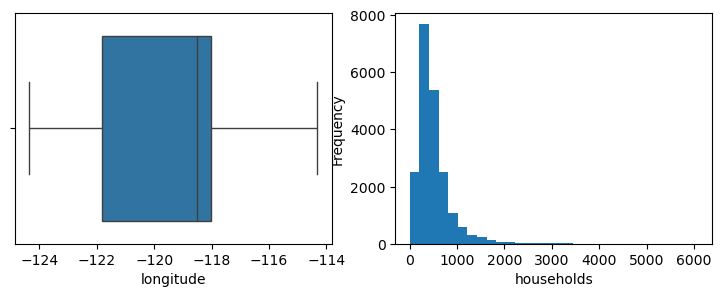

In [84]:
# Look for edge cases and tails
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.boxplot(data=df, x="longitude", ax=ax[0])

df["households"].plot(kind="hist", bins=30, ax=ax[1])
ax[1].set_xlabel('households')
plt.show()

In [111]:
# Look for highly skewed features
df.skew(numeric_only=True)

longitude            -0.297801
latitude              0.465953
housing_median_age    0.060331
total_rooms           4.147343
total_bedrooms        3.459546
population            4.935858
households            3.410438
median_income         1.646657
median_house_value    0.977763
dtype: float64

In [83]:
# Use InterQuartile Method
Q1 = df["households"].quantile(0.25)
Q3 = df["households"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["households"] < lower_bound) | 
    (df["households"] > upper_bound)
]

outliers

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY
96,-122.26,37.82,31.0,4596.0,1331.0,2048.0,1180.0,2.8345,183800.0,NEAR BAY
98,-122.26,37.82,22.0,3682.0,1270.0,2024.0,1250.0,1.2185,170000.0,NEAR BAY
100,-122.25,37.81,29.0,4656.0,1414.0,2304.0,1250.0,2.4912,257800.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20541,-121.70,38.54,13.0,6819.0,1158.0,2828.0,1115.0,4.6225,226500.0,INLAND
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND


In [87]:
# Use z-score Method
from scipy.stats import zscore
df["z_score"] = zscore(df["households"].dropna())
df["households_feature"] = df["z_score"] > 3
df[df["households_feature"]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,z_score,households_feature
95,-122.26,37.80,36.0,5329.0,2477.0,3469.0,2323.0,2.0096,130000.0,NEAR BAY,4.769455,True
104,-122.26,37.81,34.0,5871.0,1914.0,2689.0,1789.0,2.8406,335700.0,NEAR BAY,3.372721,True
116,-122.25,37.83,28.0,5022.0,1750.0,2558.0,1661.0,2.4234,218500.0,NEAR BAY,3.037923,True
283,-122.16,37.79,22.0,12842.0,2048.0,4985.0,1967.0,5.9849,371000.0,NEAR BAY,3.838299,True
485,-122.26,37.86,35.0,5161.0,1744.0,3276.0,1742.0,1.6307,253600.0,NEAR BAY,3.249787,True
...,...,...,...,...,...,...,...,...,...,...,...,...
20530,-121.76,38.57,11.0,15018.0,3008.0,7984.0,2962.0,3.1371,201800.0,INLAND,6.440827,True
20543,-121.74,38.55,33.0,6861.0,1820.0,3717.0,1767.0,1.7311,182600.0,INLAND,3.315178,True
20544,-121.76,38.55,23.0,8800.0,1857.0,6330.0,1832.0,2.0650,219400.0,INLAND,3.485192,True
20563,-121.75,38.67,9.0,12139.0,2640.0,6837.0,2358.0,3.1250,132500.0,INLAND,4.861001,True


In [ ]:
# Outliers can be simply kept

# Outliers can be removed by filtering the dataframe
df = df[(df["feature"] >= lower_bound) & (df["feature"] <= upper_bound)]

# Outliers can be clipped to upper or lower values without the need to remove the row
df["feature"] = df["feature"].clip(lower_bound, upper_bound)

# Features with potential outliers can be transformed 
df["log_feature"] = np.log(df["feature"])

### 8. INDIVIDUAL FEATURES

In [88]:
# Categorical variables
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [89]:
df["ocean_proximity"].value_counts(normalize=True) * 100

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64

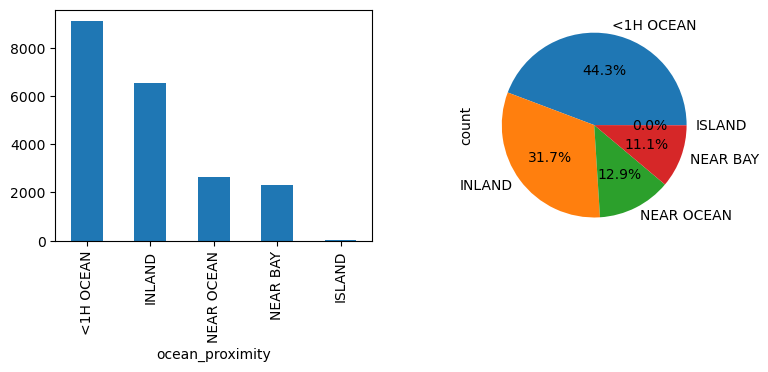

In [92]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
df["ocean_proximity"].value_counts().plot(kind="bar", ax=ax[0])
df["ocean_proximity"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
plt.show()

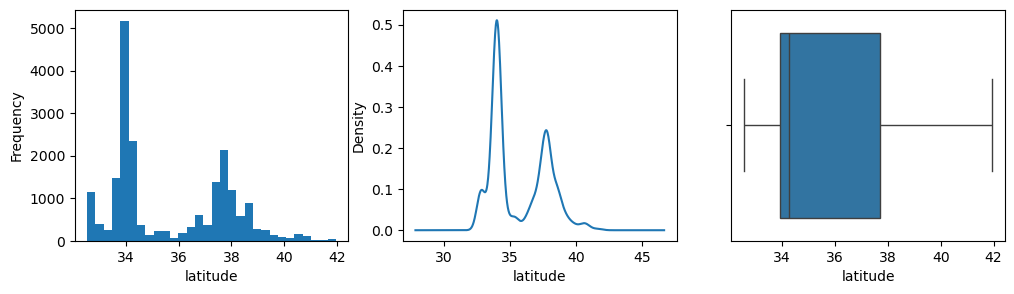

In [94]:
# Numerical variables
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
df["latitude"].plot(kind="hist", bins=30, ax=ax[0])
ax[0].set_xlabel('latitude')
df['latitude'].plot(kind='kde', ax=ax[1])
ax[1].set_xlabel('latitude')
sns.boxplot(data=df, x="latitude", ax=ax[2])
plt.show()

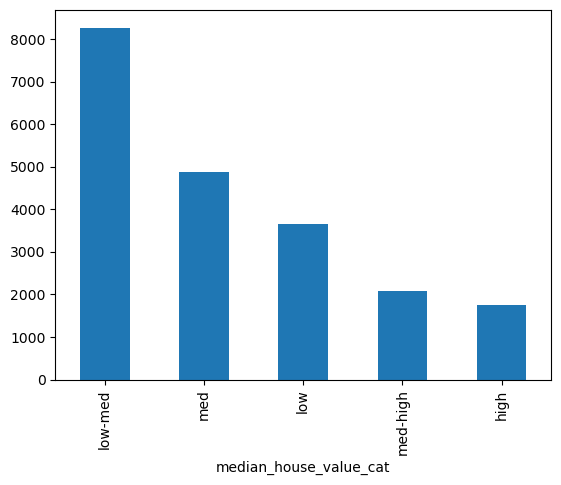

In [129]:
# It is possible to categorize a numerical variable into bins
df['median_house_value_cat'] = pd.cut(
    df["median_house_value"],
    bins=[0, 100000, 200000, 300000, 400000, 5000000],
    labels=["low", "low-med", "med", "med-high", "high"]
)

# Similarly for quantiles
# df['median_house_value_cat'] = pd.qcut(
#    df["median_house_value"], q=4,
#    labels=["0-25", "25-50", "50-75", "75-100"]
#)

df['median_house_value_cat'].value_counts().plot(kind='bar')
plt.show()

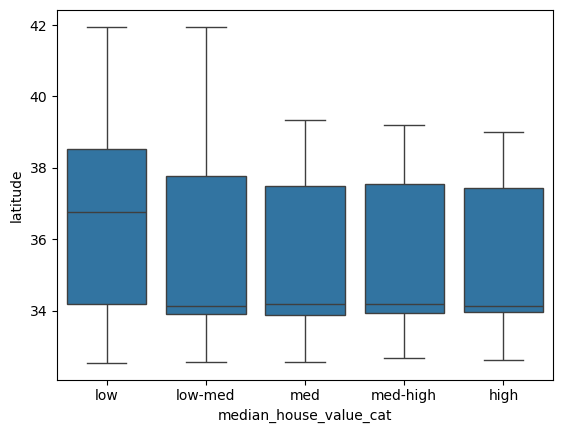

In [130]:
sns.boxplot(data=df, x="median_house_value_cat", y="latitude")
plt.show()

### 9. CATEGORICAL VARIABLES ENCODING

In [132]:
# Categorical variables can be mapped / encoded to numerical variables
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [ ]:
# Use mapping to encode words to numerical values
map_dict = {'<1H OCEAN': 0,
            'INLAND': 1,
            'NEAR OCEAN': 2,
            'NEAR BAY': 3,
            'ISLAND': 4,
}

# Note that this encoding might be carrying zero information as of "why NEAR OCEAN = 2 AND ISLAND = 4??"
df['ocean_proximity_num'] = df['ocean_proximity'].map(map_dict)

In [157]:
# Ordinal encoding --> Might take care of multiple categorical variable at the same time
# Ordinal encoding might be able to infer order of categories (e.g. cold - warm - hot, need testing)
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df['ocean_proximity_ordinal'] = encoder.fit_transform(df[['ocean_proximity']])
df


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_house_value_cat,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,ocean_proximity_ordinal
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,high,0.0,0.0,0.0,1.0,0.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0


In [158]:
# OneHot encoding --> Turns each categorical value into a new feature of [0, 1]
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
ocean_proximity_onehot = encoder.fit_transform(df[['ocean_proximity']])
df[encoder.categories_[0]] = ocean_proximity_onehot.toarray()
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_house_value_cat,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,ocean_proximity_ordinal
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,high,0.0,0.0,0.0,1.0,0.0,3.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,med-high,0.0,0.0,0.0,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,low,0.0,1.0,0.0,0.0,0.0,1.0


### 10. NUMERICAL VARIABLES SCALING

In [ ]:
# Normalization
# Normalization is a scaling technique that transforms the numerical feature to the range of values between 0 and 1
# --> Normalization is very sensitive to outliers

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['latitude_normalized'] = scaler.fit_transform(df[['latitude']])
df[['latitude', 'latitude_normalized']].head()

,latitude,latitude_normalized
0,37.88,0.567481
1,37.86,0.565356
2,37.85,0.564293
3,37.85,0.564293
4,37.85,0.564293


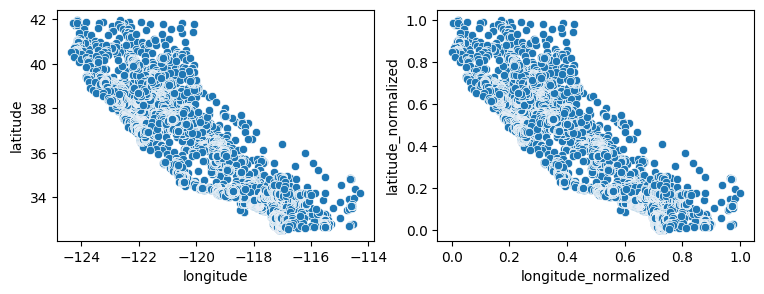

In [8]:
df['longitude_normalized'] = scaler.fit_transform(df[['longitude']])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.scatterplot(data=df, x="longitude", y="latitude", ax=ax[0])
sns.scatterplot(data=df, x="longitude_normalized", y="latitude_normalized", ax=ax[1])
plt.show()


In [9]:
# Standardization
# Standardization is a scaling technique that transforms the numerical feature to have a mean of 0 and a standard deviation of 1

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['latitude_standardized'] = scaler.fit_transform(df[['latitude']])
df[['latitude', 'latitude_standardized']].head()

,latitude,latitude_standardized
0,37.88,1.052548
1,37.86,1.043185
2,37.85,1.038503
3,37.85,1.038503
4,37.85,1.038503


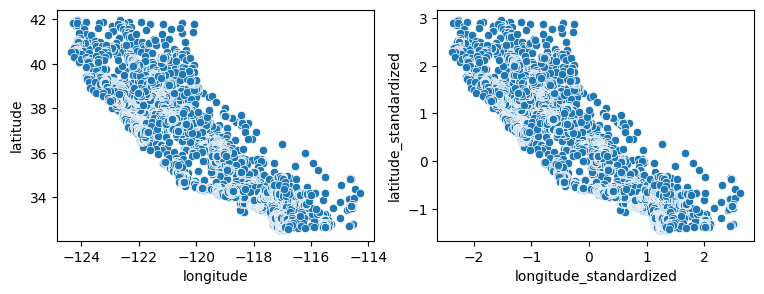

In [10]:
df['longitude_standardized'] = scaler.fit_transform(df[['longitude']])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.scatterplot(data=df, x="longitude", y="latitude", ax=ax[0])
sns.scatterplot(data=df, x="longitude_standardized", y="latitude_standardized", ax=ax[1])
plt.show()

In [12]:
# Robust scaling
# Robust scaling is a scaling technique that transforms the numerical feature using the median and the interquartile range (IQR) instead of mean and standard deviation, making it more robust to outliers
# It might be more relevant when the feature contains a lot of outliers

from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['households_robust_scaled'] = scaler.fit_transform(df[['households']])
df[['households', 'households_robust_scaled']].head()


,households,households_robust_scaled
0,126.0,-0.870769
1,1138.0,2.243077
2,177.0,-0.713846
3,219.0,-0.584615
4,259.0,-0.461538


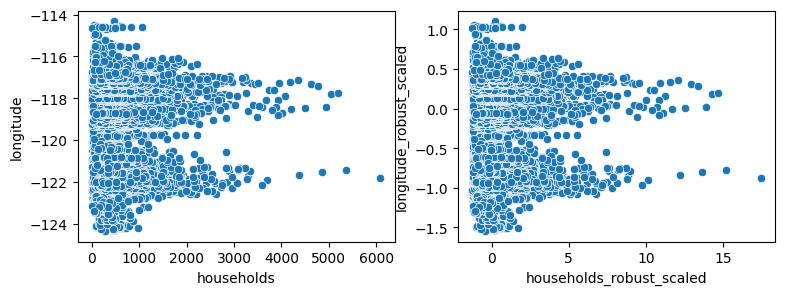

In [ ]:
df['longitude_robust_scaled'] = scaler.fit_transform(df[['longitude']])

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
sns.scatterplot(data=df, x="households", y="longitude", ax=ax[0])
sns.scatterplot(data=df, x="households_robust_scaled", y="longitude_robust_scaled", ax=ax[1])
plt.show()

| Scaling method                      | Formula                                  | What it does                                      | Sensitive to outliers? |
| ----------------------------------- | ---------------------------------------- | ------------------------------------------------- | ---------------------- |
| **Standardization**                 | ((x - \mu) / \sigma)                     | Mean 0, standard deviation 1                      | Yes                    |
| **Normalization / Min-Max scaling** | ((x - x_{\min}) / (x_{\max} - x_{\min})) | Maps values to a range, usually `[0, 1]`          | Very yes               |
| **Robust scaling**                  | ((x - \text{median}) / \text{IQR})       | Centers by median, scales by spread of middle 50% | Much less              |


| Situation / Feature type                |                      Best choice | Why                                                           |
| --------------------------------------- | -------------------------------: | ------------------------------------------------------------- |
| Most continuous numerical features      |                  **Standardize** | Good default; puts features on comparable mean/variance scale |
| Linear regression / logistic regression |                  **Standardize** | Helps coefficients and optimization behave better             |
| Ridge / Lasso / Elastic Net             |                  **Standardize** | Regularization is scale-sensitive                             |
| SVM                                     |                  **Standardize** | Margins and kernels depend heavily on feature scale           |
| k-NN                                    | **Standardize** or **Normalize** | Distance-based models need comparable feature scales          |
| k-means clustering                      |                  **Standardize** | Cluster distances are scale-sensitive                         |
| PCA                                     |                  **Standardize** | PCA is affected by feature variance                           |
| Neural networks                         | **Standardize** or **Normalize** | Helps gradient-based training                                 |
| Image pixel values                      |                    **Normalize** | Pixels naturally fit into a fixed range like `[0, 1]`         |
| Features with known hard bounds         |                    **Normalize** | Example: percentages, ratings, proportions                    |
| Features with many outliers             |                 **Robust scale** | Median and IQR are less affected by extreme values            |
| Heavy-tailed features                   |                 **Robust scale** | Better for income, revenue, transaction values, prices        |
| Financial volumes / transaction sizes   |                 **Robust scale** | Extreme values are common and can distort standardization     |
| Tree-based models                       |           **Usually no scaling** | Splits depend mostly on ordering, not absolute scale          |
| Mixed model pipeline where unsure       |                  **Standardize** | Best general-purpose starting point                           |


### 11. RELATIONSHIP BETWEEN FEATURES

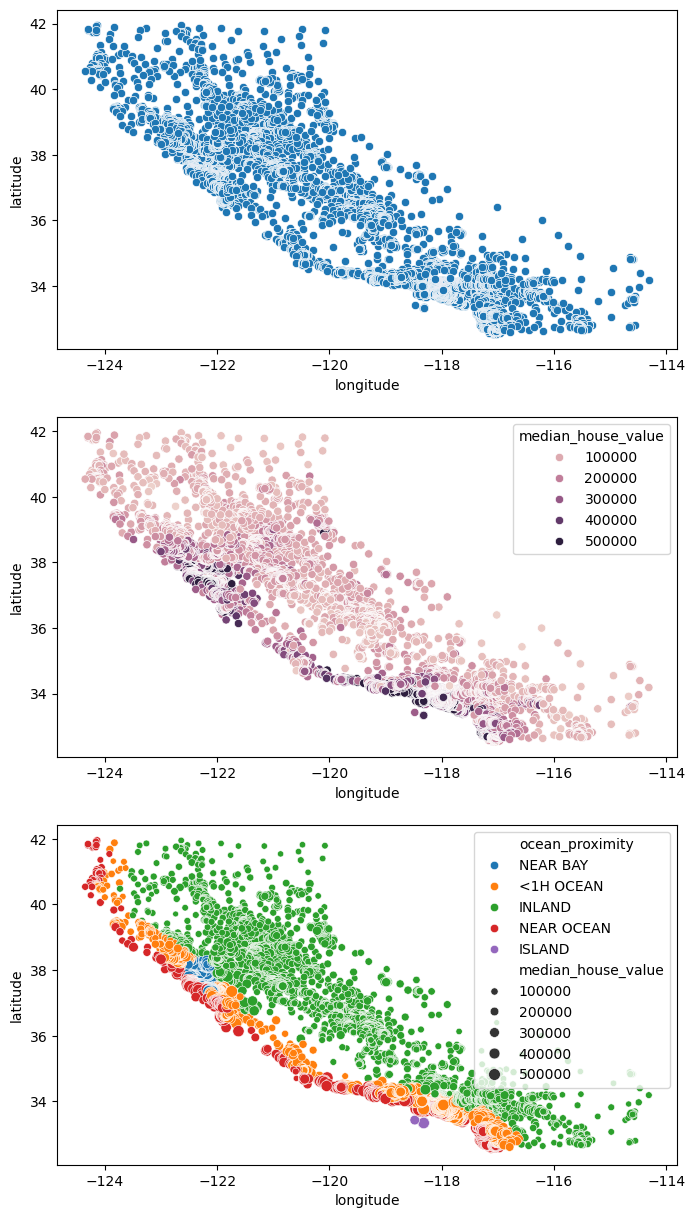

In [101]:
# Plot multiple features together
fig, ax = plt.subplots(3, 1, figsize=(8, 15))
ax = ax.flatten()
sns.scatterplot(data=df, x="longitude", y="latitude", ax=ax[0])
sns.scatterplot(data=df, x="longitude", y="latitude", hue='median_house_value', ax=ax[1])
sns.scatterplot(data=df, x="longitude", y="latitude", hue='ocean_proximity', size='median_house_value', ax=ax[2])
plt.show()

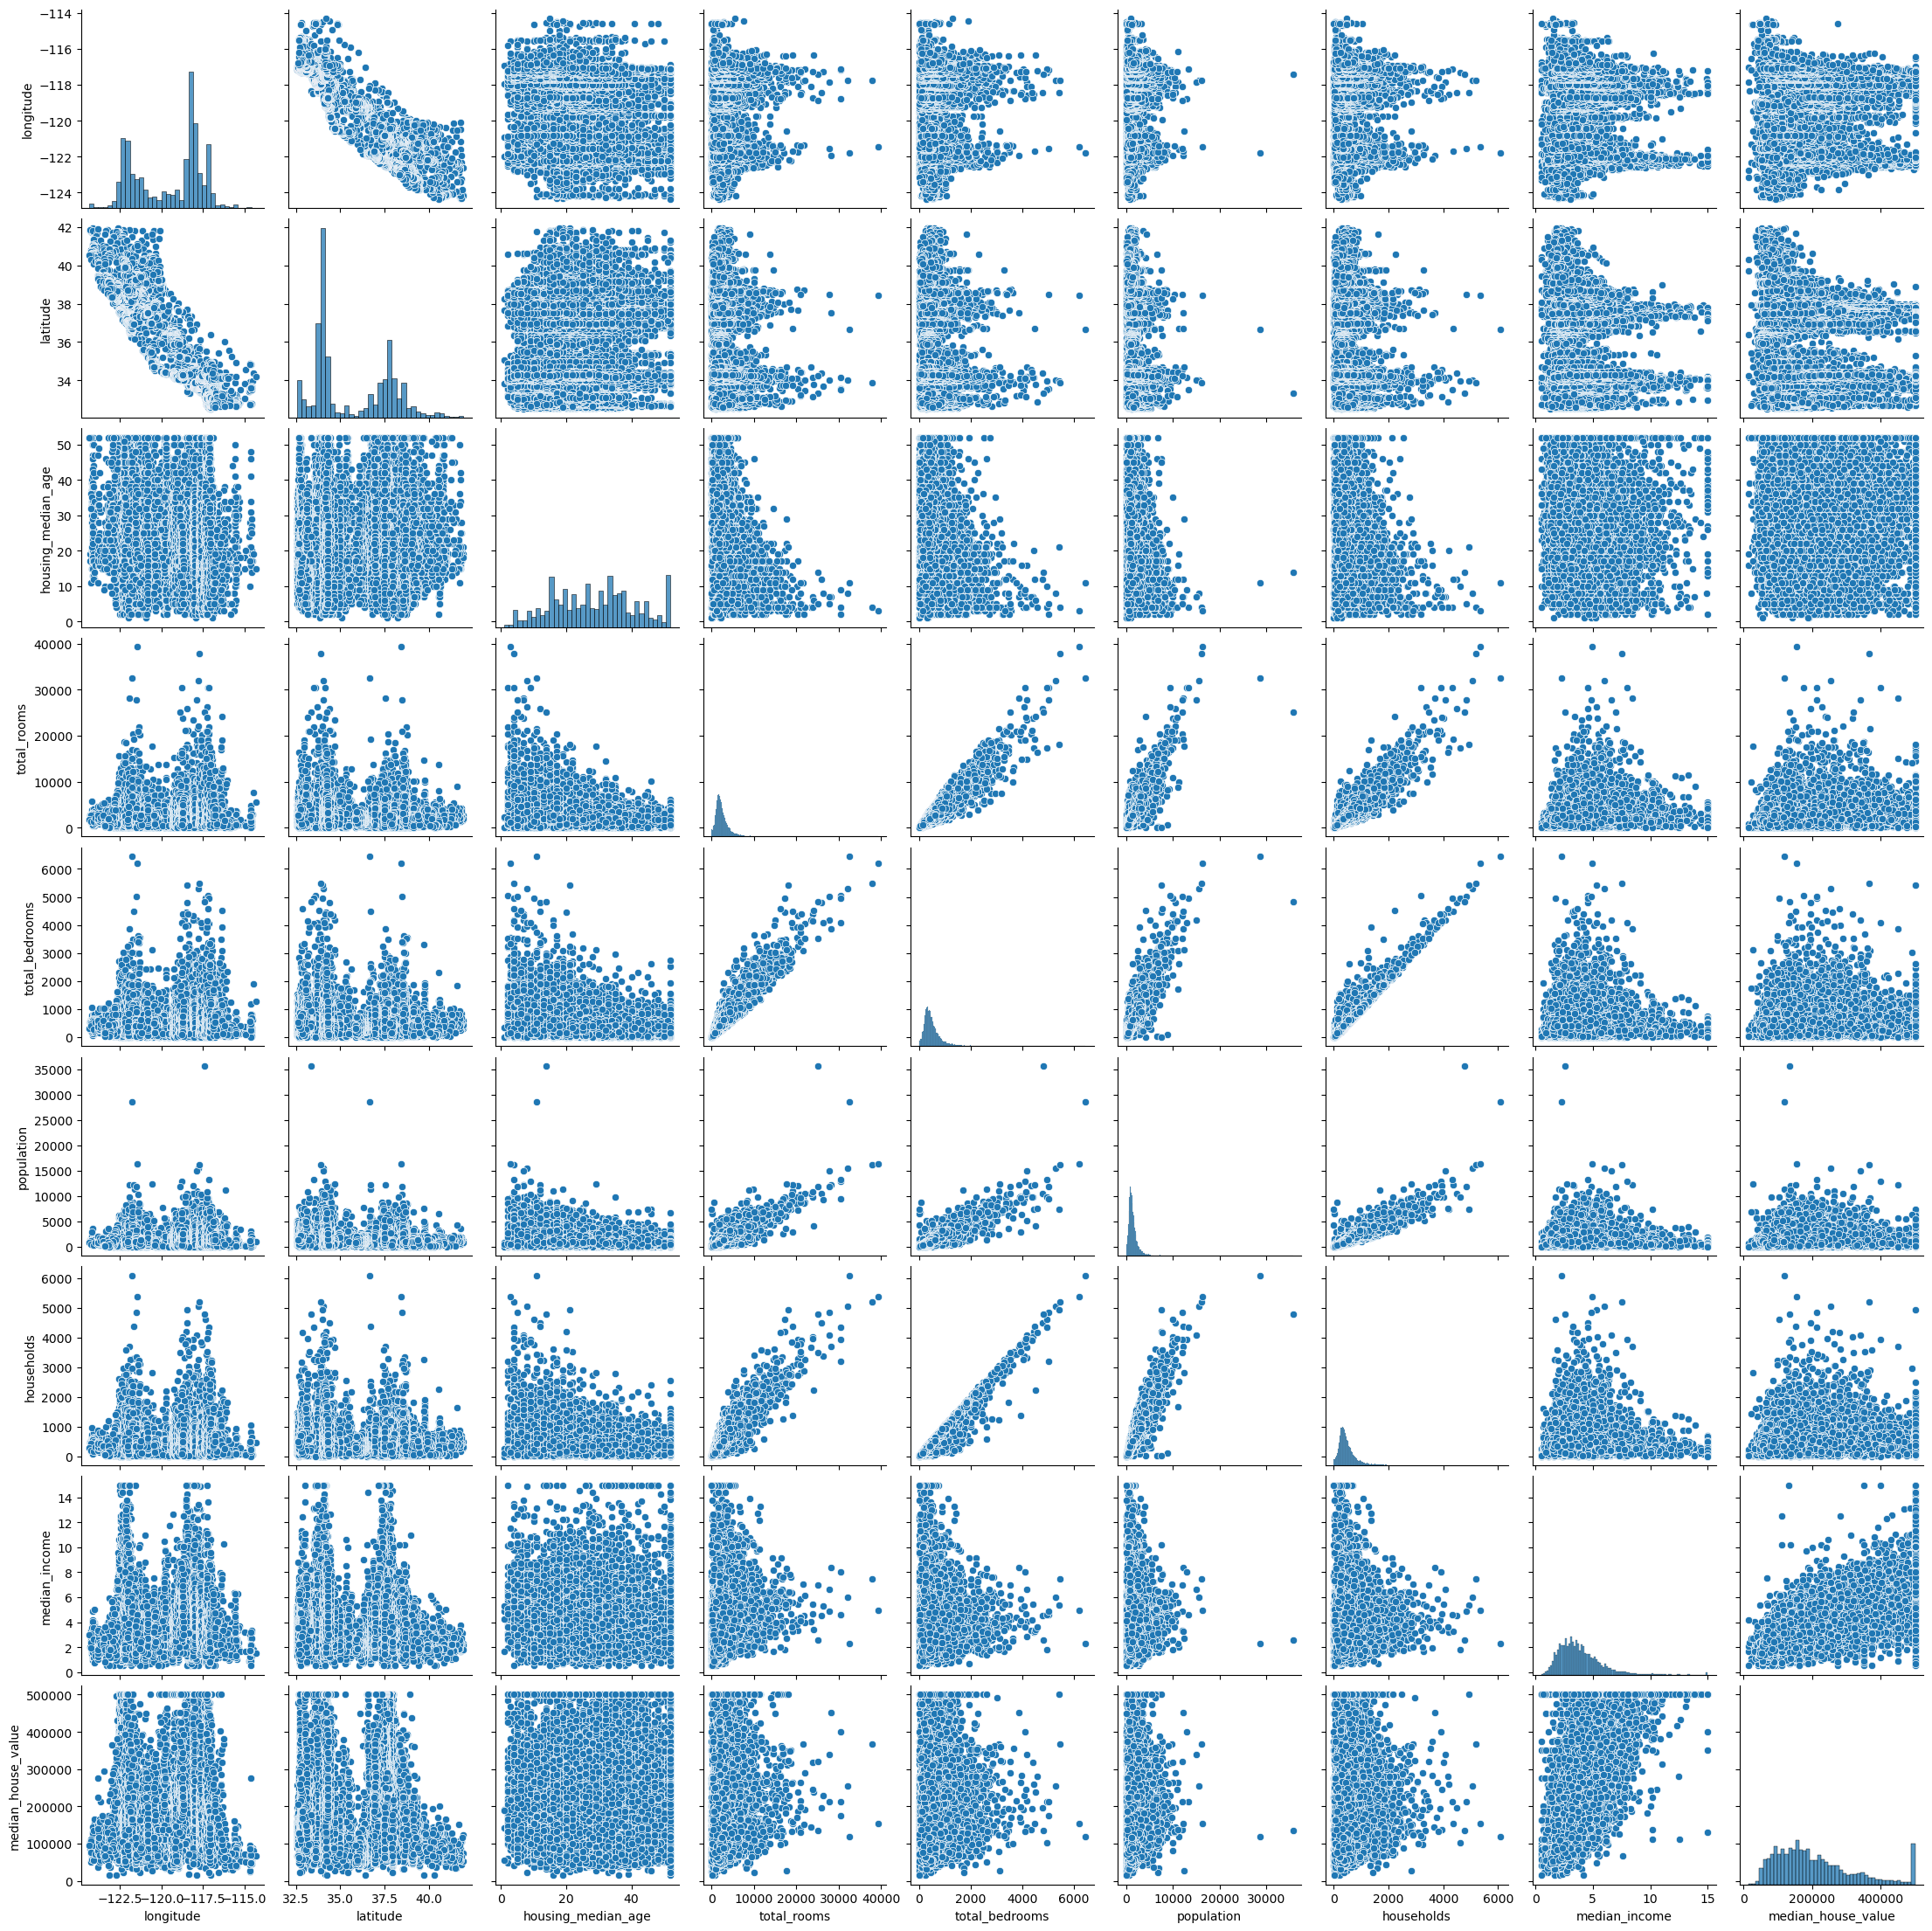

In [ ]:
# Plot all features pairwise
sns.pairplot(df)
plt.show()

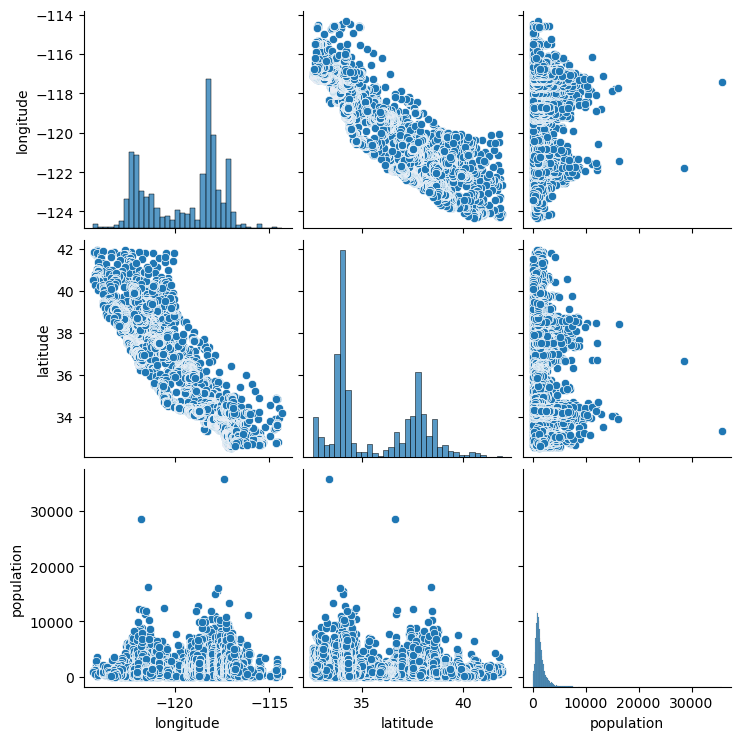

In [ ]:
# Plot selected features pairwise
sns.pairplot(df[["longitude", "latitude", "population"]])
plt.show()

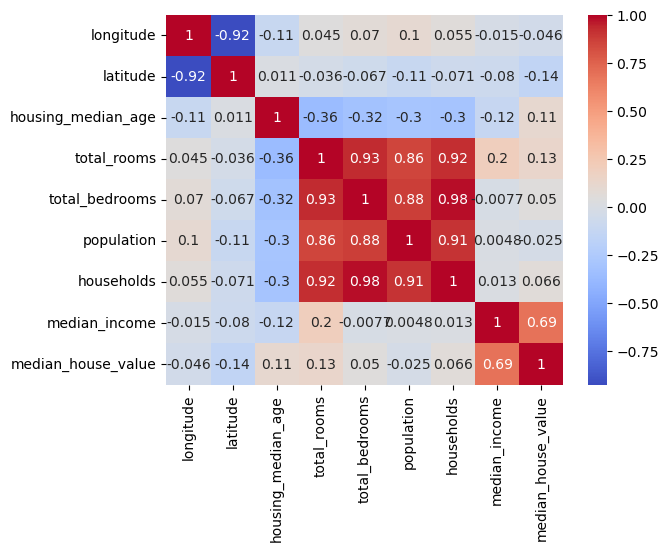

In [106]:
# Investigate correlation matrix
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [ ]:
# Investigate most correlated features with a target feature
df.corr(numeric_only=True)["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## FINAL GENERIC IMPORTANT QUESTIONS TO CONSIDER
1) What are the most important variables?
2) Which columns have missing values?
3) Which columns have suspicious values?
4) Are there duplicates?
5) Are there outliers?
6) Is the target balanced?
7) Which variables seem related to the target?
8) Which columns should be removed?
9) Which columns need transformation?
10) What assumptions did I make?